In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'insurance' dataset.
Path to dataset files: /kaggle/input/insurance


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import os
df = pd.read_csv(os.path.join(path, 'insurance.csv'))

In [ ]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
#eda
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
numeric_colum=["age","bmi","children","charges"]
categorical_column=["sex","smoker","region"]

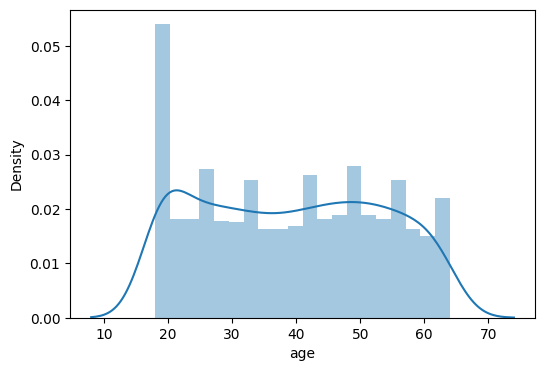

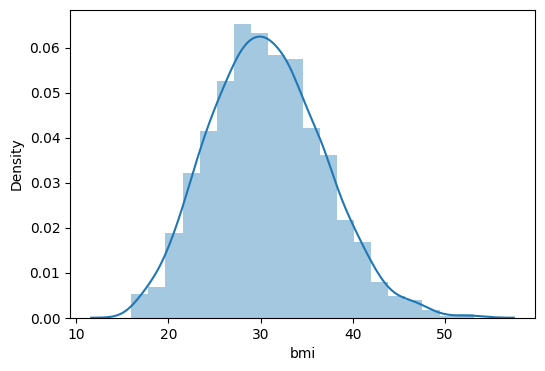

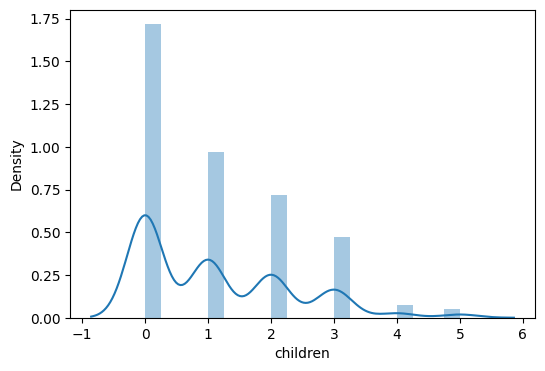

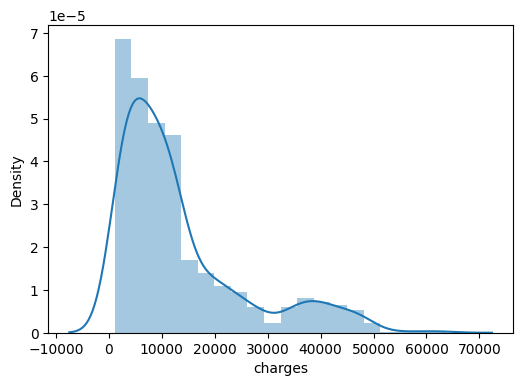

In [ ]:
for col in numeric_colum:
  plt.figure(figsize=(6,4))
  sns.distplot(df[col],kde=True,bins=20)
  plt.show()

<Axes: xlabel='children', ylabel='count'>

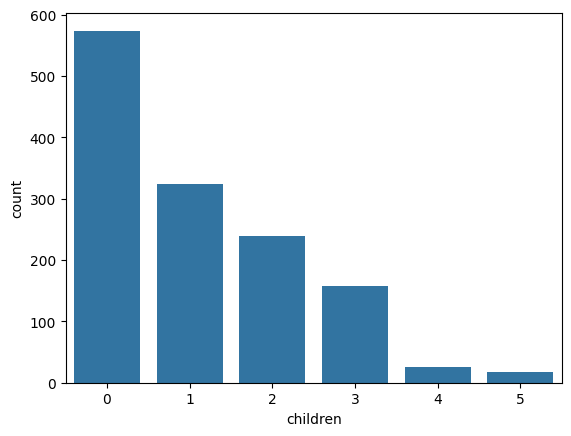

In [ ]:
sns.countplot(x='children', data=df)

<Axes: xlabel='smoker', ylabel='count'>

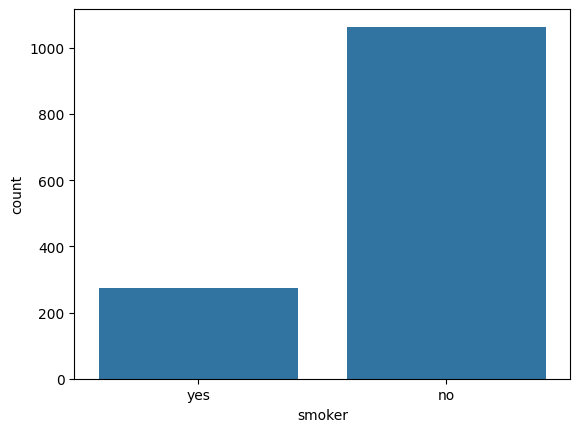

In [ ]:
sns.countplot(x='smoker', data=df)

<Axes: xlabel='region', ylabel='count'>

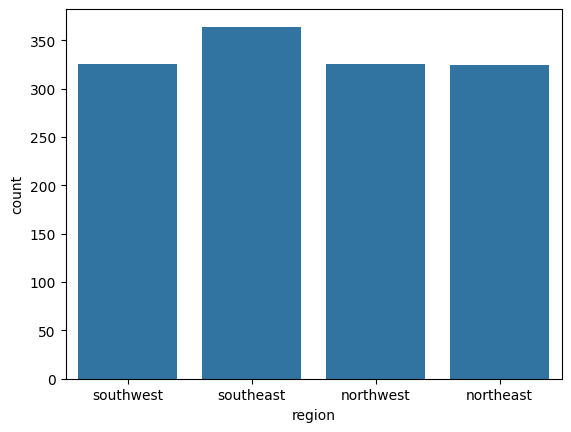

In [ ]:
sns.countplot(x='region', data=df)

<Axes: xlabel='sex', ylabel='count'>

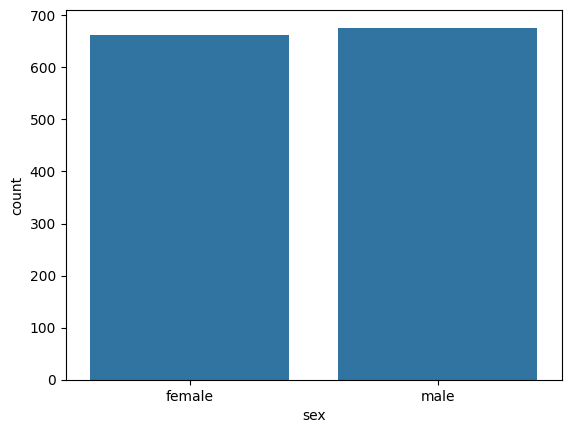

In [ ]:
sns.countplot(x='sex', data=df)

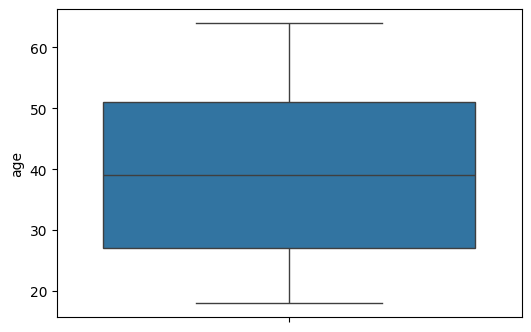

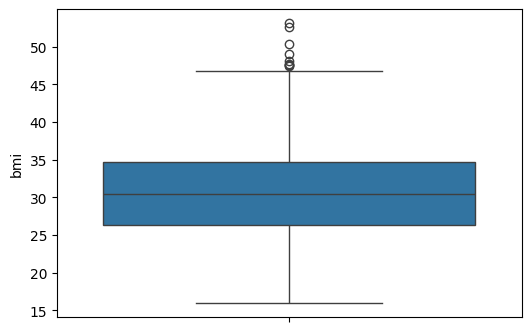

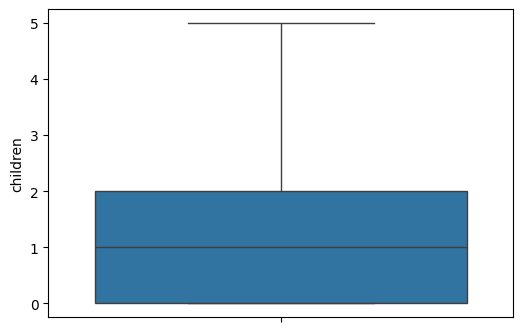

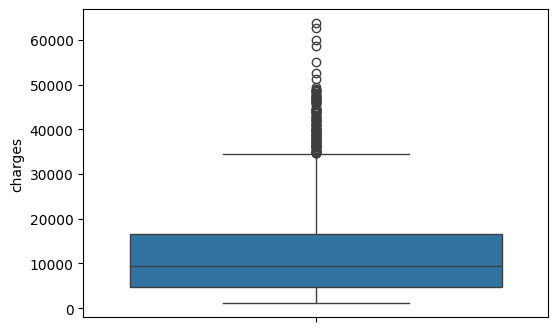

In [ ]:
for col in numeric_colum:
  plt.figure(figsize=(6,4))
  sns.boxplot(df[col])
  plt.show()

<Axes: >

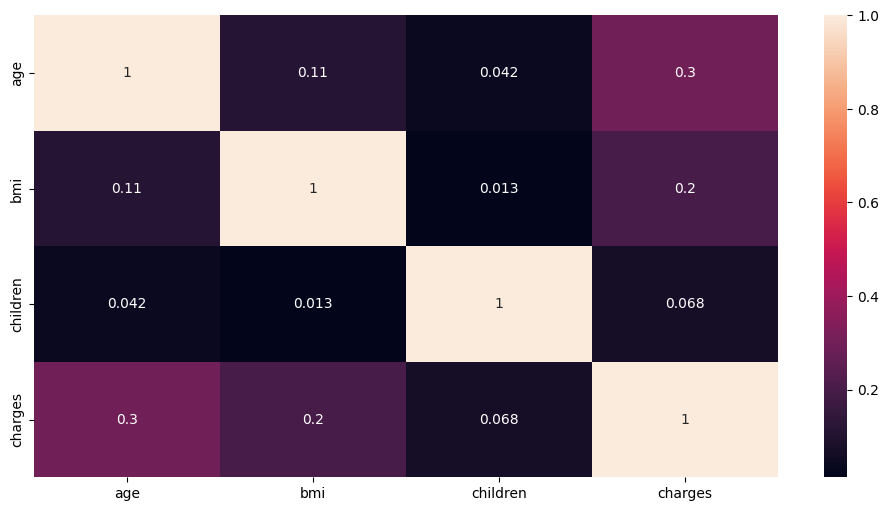

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df[numeric_colum].corr(),annot=True)

In [ ]:
# data cleaning and preprocessing

In [ ]:
df_cleaned=df.copy()

In [ ]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df_cleaned.drop_duplicates(inplace=True)

In [ ]:
df_cleaned.shape

(1337, 7)

In [ ]:
df_cleaned['sex'].value_counts()

,count
sex,
male,675
female,662


In [ ]:
df_cleaned = df.copy()
df_cleaned.drop_duplicates(inplace=True)
df_cleaned['sex'] = df_cleaned['sex'].map({'female': 1, 'male': 0})

In [ ]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [ ]:
df_cleaned['smoker'].value_counts()

,count
smoker,
no,1063
yes,274


In [ ]:
df_cleaned['smoker']=df_cleaned['smoker'].map({'yes':1,'no':0})

In [ ]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [ ]:
df_cleaned.rename(columns={'sex':'is_female','smoker':'is_smoker'},inplace=True)

In [ ]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [ ]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['region'], drop_first=True)

In [ ]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [ ]:
df_cleaned=df_cleaned.astype(int)

In [ ]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


In [ ]:
# featur engenerring and extraction

In [ ]:
df_cleaned['bmi_category'] = pd.cut(df_cleaned['bmi'], bins=[0, 18.5, 24.9, 29.9, float('inf')],
                                     labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

In [ ]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,Obese
2,28,0,33,3,0,4449,0,1,0,Obese
3,33,0,22,0,0,21984,1,0,0,Normal
4,32,0,28,0,0,3866,1,0,0,Overweight


In [ ]:
df_cleaned['bmi_category'].value_counts()

,count
bmi_category,
Obese,706
Overweight,386
Normal,221
Underweight,24


In [ ]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['bmi_category'], drop_first=True)

In [ ]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,False,True,False
1,18,0,33,1,0,1725,0,1,0,False,False,True
2,28,0,33,3,0,4449,0,1,0,False,False,True
3,33,0,22,0,0,21984,1,0,0,True,False,False
4,32,0,28,0,0,3866,1,0,0,False,True,False


In [ ]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
cols=['age', 'bmi', 'children']
scaler=StandardScaler()
df_cleaned[cols]=scaler.fit_transform(df_cleaned[cols])

In [ ]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,False,True,False
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,False,False,True
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,False,False,True
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,True,False,False
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,False,True,False


In [ ]:
# person corellation calculation

In [ ]:
from scipy.stats import pearsonr
selected_features=['age','bmi','children','is_female','is_smoker','region_northwest','region_southeast','region_southwest','bmi_category_Normal','bmi_category_Overweight','bmi_category_Obese']
correlations={feature:pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
for feature in selected_features}
correlation_df=pd.DataFrame(list(correlations.items()),columns=['Feature','pearson Correlation'])
correlation_df.sort_values(by='pearson Correlation',ascending=False)
correlation_df

,Feature,pearson Correlation
0,age,0.298309
1,bmi,0.196236
2,children,0.067390
3,is_female,-0.058046
4,is_smoker,0.787234
5,region_northwest,-0.038695
6,region_southeast,0.073577
7,region_southwest,-0.043637
8,bmi_category_Normal,-0.104042
9,bmi_category_Overweight,-0.120601


In [ ]:
# chi squar test

In [ ]:
cat_features=['is_female','is_smoker','region_northwest','region_southeast','region_southwest','bmi_category_Normal','bmi_category_Overweight','bmi_category_Obese']

In [ ]:
from scipy.stats import chi2_contingency


In [ ]:
alpha=0.05
df_cleaned['charges_bin']=pd.qcut(df_cleaned['charges'],q=4,labels=False)
chi2_result={}

In [ ]:
for col in cat_features:
  contingency=pd.crosstab(df_cleaned['charges_bin'],df_cleaned[col])
  chi2,p,_,_=chi2_contingency(contingency)
  decision="reject null hypothesis" if p<alpha else "fail to reject null hypothesis"
  chi2_result[col]={
      'chi2_stattistic':chi2,
      'p_value':p,
      'decision':decision
  }
  chi2_df=pd.DataFrame(chi2_result).T
  chi2_df.sort_values(by='p_value',ascending=True)


In [ ]:
chi2_df

,chi2_stattistic,p_value,decision
is_female,10.258784,0.01649,reject null hypothesis
is_smoker,848.219178,0.0,reject null hypothesis
region_northwest,1.13424,0.768815,fail to reject null hypothesis
region_southeast,15.998167,0.001135,reject null hypothesis
region_southwest,5.091893,0.165191,fail to reject null hypothesis
bmi_category_Normal,3.708088,0.29476,fail to reject null hypothesis
bmi_category_Overweight,4.25149,0.235557,fail to reject null hypothesis
bmi_category_Obese,8.515711,0.036473,reject null hypothesis


In [ ]:
final_df=df_cleaned[['age', 'bmi', 'children', 'is_female', 'is_smoker', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_category_Normal', 'bmi_category_Overweight', 'charges']]

In [ ]:
final_df.head()

,age,bmi,children,is_female,is_smoker,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,charges
0,-1.440418,-0.517949,-0.909234,1,1,0,0,1,False,True,16884
1,-1.511647,0.462463,-0.079442,0,0,0,1,0,False,False,1725
2,-0.799350,0.462463,1.580143,0,0,0,1,0,False,False,4449
3,-0.443201,-1.334960,-0.909234,0,0,1,0,0,True,False,21984
4,-0.514431,-0.354547,-0.909234,0,0,1,0,0,False,True,3866


In [ ]:
final_df

,age,bmi,children,is_female,is_smoker,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,charges
0,-1.440418,-0.517949,-0.909234,1,1,0,0,1,False,True,16884
1,-1.511647,0.462463,-0.079442,0,0,0,1,0,False,False,1725
2,-0.799350,0.462463,1.580143,0,0,0,1,0,False,False,4449
3,-0.443201,-1.334960,-0.909234,0,0,1,0,0,True,False,21984
4,-0.514431,-0.354547,-0.909234,0,0,1,0,0,False,True,3866
...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,-0.027743,1.580143,0,0,1,0,0,False,False,10600
1334,-1.511647,0.135659,-0.909234,1,0,0,0,0,False,False,2205
1335,-1.511647,0.952670,-0.909234,1,0,0,1,0,False,False,1629
1336,-1.297958,-0.844753,-0.909234,1,0,0,0,1,False,True,2007


In [ ]:
from sklearn.model_selection import train_test_split
x = final_df.drop('charges',axis=1)
y = final_df['charges']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
y_pred

array([ 8156.19394617,  4933.75760053, 14659.23171745, 32300.63103338,
        9039.90158088, 13387.03916911, 30570.26020911,  1104.74792819,
       11134.1614764 , 10122.21744928, 10712.95565054, 32199.37215695,
       31722.18889679, 16541.09247783, 10830.14565297,  8271.71418608,
        4946.5360794 , 32350.50595099,  2903.32781083,  4007.86329978,
        4529.03827785, 29262.87419447, 14282.23111062, 29307.7726162 ,
       31478.14913864,  6141.4398137 , 35274.30692545, 37340.71514638,
       12529.99811045, 14562.40991516,  7656.6049997 , 13111.17589832,
         387.11476907, 11091.02724483, 38345.96350252, 12964.1960526 ,
        3435.8594348 ,  4209.71652818, 31209.48669128,  8104.60863626,
        6682.45827838, 30546.7502841 , 35155.7627582 , 13255.05127369,
        7689.73703345,  2578.3432587 ,  5840.81221447,  7500.17432944,
        3427.27751495, 10083.50193654,  7584.68733679, 11323.31816071,
       30631.42835383,  4433.46105154, 11301.26702621, 11015.61730915,
      

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 35264010.28133385
R-squared: 0.8080933741019868


In [ ]:
n=x_test.shape[0]
p=x_test.shape[1]
adjusted_r2=1-(1-r2)*(n-1)/(n-p-1)
print(f"adjusted_r2: {adjusted_r2}")

adjusted_r2: 0.8006261902149046
